In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shutil

In [ ]:
# Dataset from Kaggle
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

print("Main folder:", os.listdir(path))

train_set = os.path.join(path, "train")
test_set = os.path.join(path, "test")

print("Train folder:", os.listdir(train_set))
print("Test folder:", os.listdir(test_set))


Using Colab cache for faster access to the 'emotion-detection-fer' dataset.
Main folder: ['test', 'train']
Train folder: ['fearful', 'disgusted', 'angry', 'neutral', 'sad', 'surprised', 'happy']
Test folder: ['fearful', 'disgusted', 'angry', 'neutral', 'sad', 'surprised', 'happy']


In [ ]:
emotions = []
emotions_count = []
TARGET_TOTAL = 5000



#Orginal data
i=0
for emotion in os.listdir(train_set):
  emotions.append(emotion)
  emotions_count.append(len(os.listdir(os.path.join(train_set, emotion))))
  print(emotion, emotions_count[i])
  i+=1

emotions = np.array(emotions)
emotions_count = np.array(emotions_count)


print(emotions_count)
total_count = np.sum(emotions_count)

print(total_count)

#Proporcje
proportions = emotions_count / total_count
print(proportions)




fearful 4097
disgusted 436
angry 3995
neutral 4965
sad 4830
surprised 3171
happy 7215
[4097  436 3995 4965 4830 3171 7215]
28709
[0.14270786 0.01518688 0.13915497 0.17294228 0.16823992 0.11045317
 0.25131492]


In [ ]:
import shutil
import os # Ensure os is imported

#Tworzenie nowego train set
new_train_set = '/content/drive/MyDrive/MSI - projekt/Dataset'

# Remove existing entry (file or directory) to ensure a clean start
if os.path.exists(new_train_set):
    if os.path.isdir(new_train_set):
        shutil.rmtree(new_train_set)
    elif os.path.isfile(new_train_set):
        os.remove(new_train_set)

os.makedirs(new_train_set, exist_ok=True)

new_count = (proportions * TARGET_TOTAL).astype(int)


for i in range(len(emotions)):
  emotion = emotions[i]
  count = new_count[i]


  new_folder = os.path.join(new_train_set, emotions[i])
  os.makedirs(new_folder, exist_ok=True)

  old_folder = os.path.join(train_set, emotions[i])

  all_images = np.array(os.listdir(old_folder))


  selected_images = np.random.choice(all_images, size=count, replace=False)

  for img in selected_images:
        src_path = os.path.join(old_folder, img)
        dest_path = os.path.join(new_folder, img)
        shutil.copy2(src_path, dest_path)

In [ ]:
for emotion in os.listdir(new_train_set):
  print(emotion, len(os.listdir(os.path.join(new_train_set, emotion))))

In [ ]:
TARGET_TOTAL_TEST = TARGET_TOTAL * 0.2

new_test_set = '/content/drive/MyDrive/MSI - projekt/Test set'


test_new_count = (proportions * TARGET_TOTAL_TEST).astype(int)


for i in range(len(emotions)):
  emotion = emotions[i]
  count = test_new_count[i]


  new_folder_test = os.path.join(new_test_set, emotions[i])
  os.makedirs(new_folder_test, exist_ok=True)

  old_folder_test = os.path.join(test_set, emotions[i])

  all_images_test = np.array(os.listdir(old_folder_test))


  selected_images_test = np.random.choice(all_images_test, size=count, replace=False)

  for img in selected_images_test:
        src_path = os.path.join(old_folder_test, img)
        dest_path = os.path.join(new_folder_test, img)
        shutil.copy2(src_path, dest_path)


In [ ]:
for emotion in os.listdir(new_test_set):
  print(emotion, len(os.listdir(os.path.join(new_test_set, emotion))))

NameError: name 'new_test_set' is not defined

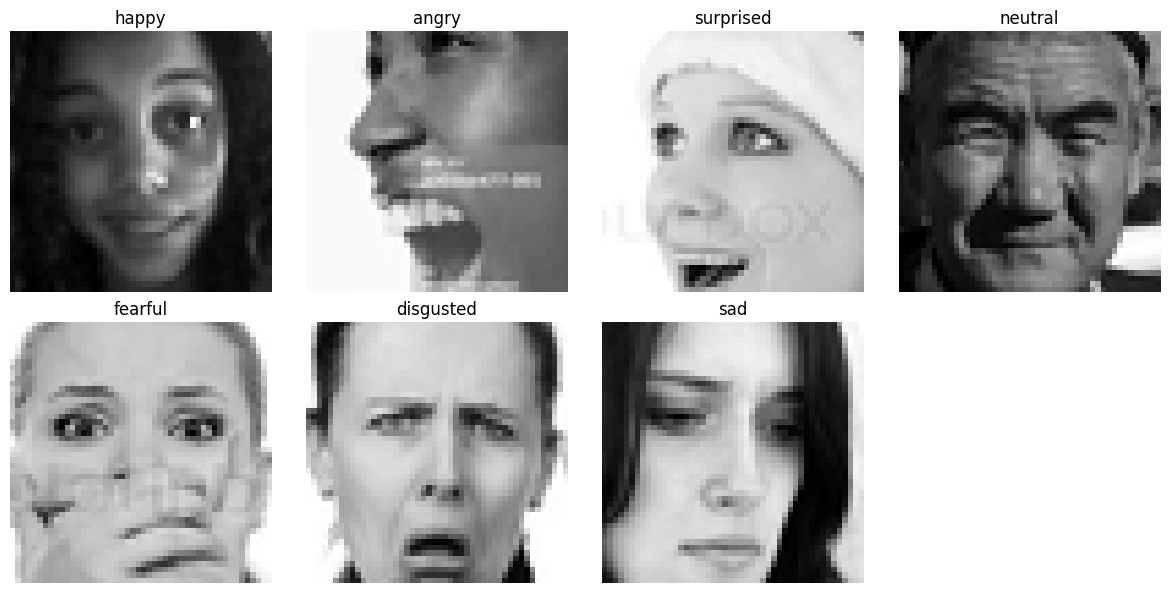

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np # Import numpy for random.choice

# Get the list of emotions from the new_train_set
emotions_list = os.listdir(new_train_set)

# Prepare lists to store image paths and labels
image_paths = []
image_labels = []

# Collect one random image path and its label for each emotion
for emotion in emotions_list:
    emotion_folder = os.path.join(new_train_set, emotion)
    if os.path.isdir(emotion_folder):
        images_in_folder = os.listdir(emotion_folder)
        if images_in_folder:
            # Randomly select one image from each folder
            selected_image = np.random.choice(images_in_folder)
            image_path = os.path.join(emotion_folder, selected_image)
            image_paths.append(image_path)
            image_labels.append(emotion)

# Determine the grid size for the collage
num_images = len(image_paths)
if num_images == 0:
    print("No images found to create a collage.")
else:
    # A 2x4 grid will accommodate 7 emotions nicely, leaving one empty spot.
    # For a general solution, calculate rows and columns dynamically.
    num_cols = 4
    num_rows = (num_images + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i in range(num_images):
        img = plt.imread(image_paths[i])
        axes[i].imshow(img, cmap='gray') # Display in grayscale
        axes[i].set_title(image_labels[i])
        axes[i].axis('off') # Hide axes ticks and labels

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()